# Analysis of data for the Essential FFPE Panel

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import cohen_kappa_score
from sklearn.neighbors import NearestNeighbors
from scipy.stats import gaussian_kde
from sklearn.mixture import GaussianMixture

from tqdm import trange

### BatchDetect module imports

Import project-specific helpers from the `batchdetect` package:

- `load_thal_cross_lot_covs` and related loaders for Thalassemia data.
- `HeavyMixture` and `parametric_bootstrap_lrt` for mixture modeling and
  parametric bootstrap-based likelihood ratio tests.
- Correlation-based clustering utilities:
  `cluster_hierarchical_corr`, `cluster_spectral_corr`,
  `cluster_pca_kmeans_corr`.
- Correlation preprocessing helpers: `normalize_mat` and `get_correlations`.

These functions implement the main batch-detection and clustering methods used
throughout the analysis.


In [2]:
from batchdetect.loader import load_thal_cross_lot_covs
from batchdetect.mixture import HeavyMixture,parametric_bootstrap_lrt

In [3]:
df_thal_likelihoods = pd.read_csv('../likelihoods_thal131.csv')
print(df_thal_likelihoods.head())
snames = df_thal_likelihoods['Sample Name'].values
likelihoods = df_thal_likelihoods['Likelihood'].values
y_hat = df_thal_likelihoods['Label'].values

                      Sample Name  Likelihood  Label
0     RDvGMpTHALD2d200302iM1-PB05   39.361303      0
1     RDvGMpTHALD2d200302iM1-PB06   39.298358      0
2     RDvGMpTHALD2d200302iM1-PB07   66.229424      0
3      RDvGMpTHALD2d200302iM1-TV2   38.732541      0
4  RDvGMpTHALD2d200302iM1-aTHAL31 -214.132134      0


### Load  count data and metadata

Load the cross-lot coverage
matrix and associated metadata:

- `counts_thal`: amplicon-level coverage counts per sample.
- `y_thal`: sample labels from the loader (if provided).
- `sample_id`: sample identifiers.
- `features`: amplicon/feature annotations.

These raw counts are used for correlation-based clustering and neighborhood
analysis.


In [4]:
counts_thal,y_thal,sample_id,features,_ = load_thal_cross_lot_covs()
counts_thal = counts_thal[:-1]
y_thal = y_thal[:-1]
sample_id = sample_id[:-1]

In [5]:
index_homozygous_del = [18,19,24,32,36,57]
counts_thal_new = np.delete(counts_thal, index_homozygous_del, axis=0)
likelihoods_new = np.delete(likelihoods, index_homozygous_del)
y_new = np.delete(y_hat, index_homozygous_del)
snames_new = np.delete(snames,index_homozygous_del)

In [29]:
def null_factory():
    return HeavyMixture(
                n_components=1,
                component_distribution='student_t',
                n_init=3,
                max_iter=1000,
            )   

def alt_factory():
            return HeavyMixture(
                n_components=2,
                component_distribution='student_t',
                n_init=3,
                max_iter=1000,
            )   

In [7]:
n_rep = 3
rng = np.random.default_rng(2021)
res_list = []
for i in trange(n_rep):
    idx = rng.choice(len(y_new),replace=True,size=len(y_new))
    X_sub = likelihoods_new[idx]
    y_sub = y_new[idx]
    res = parametric_bootstrap_lrt(
            X_sub,  
            null_model_factory=null_factory,
            alt_model_factory=alt_factory,
            n_bootstrap=500,
            random_state=i,
        )
    res_list.append(res)

100%|████████████████████████████████████████████████████████████████████████| 3/3 [00:13<00:00,  4.62s/it]


In [8]:
print([res['p_value'] for res in res_list])

[np.float64(0.003992015968063872), np.float64(0.001996007984031936), np.float64(0.001996007984031936)]


In [9]:
like_pos = likelihoods_new[y_new==1]
like_pos

array([  12.67796844,    7.83451641,  -60.38870443,  -33.43760423,
        -96.62536323,  -12.8118925 ,  -86.39409874,    0.34155039,
        -33.44017385,  -52.86615521,  -28.84583715,  -19.52291205,
        -51.01887955,  -27.20388229,  -44.74562733, -124.2799388 ,
        -39.03131613,  -13.8171304 ,    1.07862225,  -67.43010064,
          2.13194689,    6.8615726 ,  -65.68008795, -182.9654755 ,
        -94.12355748,  -48.63271888, -176.1055493 , -100.6257304 ,
       -144.1033432 ,   -6.84460844, -195.7117892 ,  -27.66798359,
       -143.3146735 ,   15.30143668,  -27.8526561 ,   -6.93426742,
        -24.29360738,  -63.45542755,  -35.31430356,   17.64907871,
        -13.86521088,  -80.26681847,  -95.11362832,   10.5744734 ,
        -59.33269692])

In [10]:
snames_pos = snames_new[y_new==1]
snames_pos[like_pos< -100]

array(['SRvSMpTha-Lib2-36-0p5', 'SRvSMpTha-Lib5-20-0p5',
       'SRvSMpTha-Lib5-33-0p5', 'SRvSMpTha-Lib5-4-0p5',
       'SRvSMpTha-Lib5-45-0p5', 'SRvSMpTha-Lib5-6-0p5',
       'SRvSMpThad190712iN2-Lib1-7-0p5'], dtype=object)

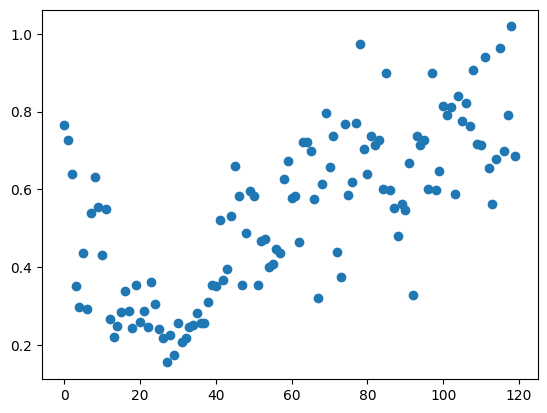

In [20]:
plt.scatter(np.arange(120),counts_thal[sample_id=='SRvSMpTha-Lib2-36-0p5']/np.mean(counts_thal,axis=0))

In [11]:
like_pos_sub = like_pos[like_pos>-100]

In [12]:
snames_new[y_new==0]

array(['RDvGMpTHALD2d200302iM1-PB05', 'RDvGMpTHALD2d200302iM1-PB06',
       'RDvGMpTHALD2d200302iM1-PB07', 'RDvGMpTHALD2d200302iM1-TV2',
       'RDvGMpTHALD2d200302iM1-aTHAL31', 'RDvGMpTHALD2d200302iM1-aTHAL32',
       'RDvGMpTHALD2d200302iM1-aTHAL33', 'RDvGMpTHALD2d200302iM1-aTHAL34',
       'RDvGMpTHALD2d200302iM1-aTHAL35', 'RDvGMpTHALD2d200302iM1-aTHAL36',
       'RDvGMpTHALD2d200302iM1-aTHAL37', 'RDvGMpTHALD2d200302iM1-aTHAL38',
       'RDvGMpTHALD2d200302iM1-aTHAL39', 'RDvGMpTHALD2d200302iM1-aTHAL40',
       'RDvGMpTHALD2d200302iM1-aTHAL41', 'RDvGMpTHALD2d200302iM1-aTHAL42',
       'RDvGMpTHALD2d200302iM1-aTHAL43', 'RDvGMpTHALD2d200302iM1-aTHAL44',
       'RDvGMpTHALD2d200302iM1-aTHAL47', 'RDvGMpTHALD2d200302iM1-aTHAL48',
       'RDvGMpTHALD2d200302iM1-aTHAL49', 'RDvGMpTHALD2d200302iM1-aTHAL50',
       'RDvGMpTHALD2d200302iM1-aTHAL52', 'RDvGMpTHALD2d200302iM1-aTHAL53',
       'RDvGMpTHALD2d200302iM1-aTHAL54', 'RDvGMpTHALD2d200302iM1-aTHAL55',
       'RDvGMpTHALD2d200302iM1-aTHAL56

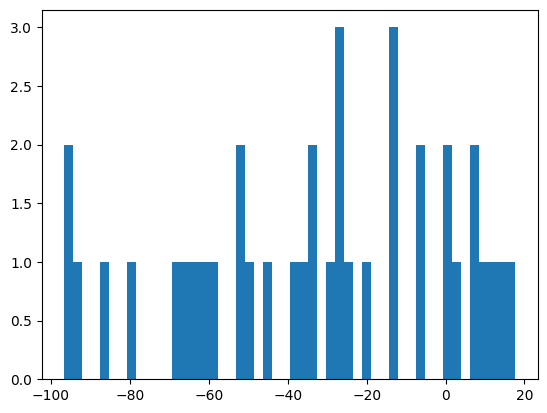

In [13]:
plt.hist(like_pos_sub,50);

In [14]:
n_rep = 30
rng = np.random.default_rng(2021)
res_list_pos = []
for i in trange(n_rep):
    idx = rng.choice(len(like_pos_sub),replace=True,size=len(like_pos_sub))
    X_sub = like_pos_sub[idx]
    y_sub = y_new[idx]
    res = parametric_bootstrap_lrt(
            X_sub,  
            null_model_factory=null_factory,
            alt_model_factory=alt_factory,
            n_bootstrap=500,
            random_state=i,
        )
    res_list_pos.append(res)

100%|██████████████████████████████████████████████████████████████████████| 30/30 [02:36<00:00,  5.22s/it]


In [21]:
n_rep = 30
rng = np.random.default_rng(2021)
res_list_pos2 = []
for i in trange(n_rep):
    idx = rng.choice(len(like_pos),replace=True,size=len(like_pos))
    X_sub = like_pos[idx]
    y_sub = y_new[idx]
    res = parametric_bootstrap_lrt(
            X_sub,  
            null_model_factory=null_factory,
            alt_model_factory=alt_factory,
            n_bootstrap=500,
            random_state=i,
        )
    res_list_pos2.append(res)

100%|██████████████████████████████████████████████████████████████████████| 30/30 [02:33<00:00,  5.12s/it]


In [15]:
a = np.array([res['p_value'] for res in res_list_pos])
print(a)
print(np.mean(a))
print(np.std(a))

[0.09580838 0.78842315 0.28143713 0.52694611 0.1237525  0.03792415
 0.30938124 0.03992016 0.0239521  0.01397206 0.46706587 0.02195609
 0.33333333 0.01596806 0.00598802 0.03193613 0.73652695 0.1257485
 0.00598802 0.41716567 0.37724551 0.25149701 0.01796407 0.40718563
 0.01397206 0.42914172 0.01796407 0.46706587 0.03193613 0.07185629]
0.21630073186959417
0.22679106333036406


In [23]:
a2 = np.array([res['p_value'] for res in res_list_pos2])
print(a2)
print(np.mean(a2))
print(np.std(a2))

[0.03393214 0.00598802 0.0239521  0.03393214 0.01796407 0.01397206
 0.02994012 0.06986028 0.01397206 0.00998004 0.00798403 0.01197605
 0.01397206 0.00798403 0.07984032 0.0239521  0.01596806 0.01996008
 0.03393214 0.02195609 0.15169661 0.02794411 0.02195609 0.06387226
 0.02195609 0.00798403 0.30538922 0.05189621 0.04590818 0.00598802]
0.039853626081171
0.05731586732484154


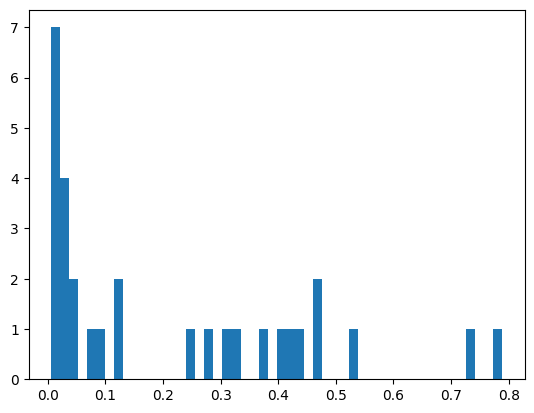

In [24]:
plt.hist(a,50);

(array([23.,  3.,  2.,  0.,  1.,  0.,  0.,  0.,  0.,  1.]),
 array([0.00598802, 0.03592814, 0.06586826, 0.09580838, 0.1257485 ,
        0.15568862, 0.18562874, 0.21556886, 0.24550898, 0.2754491 ,
        0.30538922]),
 <BarContainer object of 10 artists>)

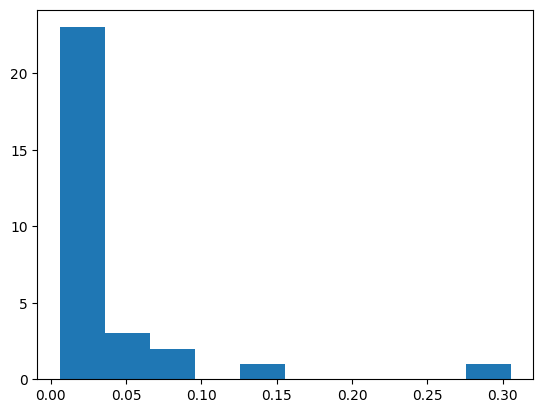

In [25]:
plt.hist(a2)

In [30]:
n_rep = 30
rng = np.random.default_rng(2021)
res_list_pos3 = []
for i in trange(n_rep):
    idx = rng.choice(len(like_pos),replace=True,size=len(like_pos))
    X_sub = like_pos[idx]
    y_sub = y_new[idx]
    res = parametric_bootstrap_lrt(
            X_sub,  
            null_model_factory=null_factory,
            alt_model_factory=alt_factory,
            n_bootstrap=500,
            random_state=i,
        )
    res_list_pos3.append(res)

100%|██████████████████████████████████████████████████████████████████████| 30/30 [02:15<00:00,  4.50s/it]


In [31]:
a3 = np.array([res['p_value'] for res in res_list_pos3])
print(a3)
print(np.mean(a3))
print(np.std(a3))

[0.05788423 0.01596806 0.04191617 0.03592814 0.01596806 0.01796407
 0.0499002  0.11576846 0.02794411 0.03393214 0.01996008 0.03992016
 0.0259481  0.01596806 0.1237525  0.03792415 0.02994012 0.05389222
 0.05788423 0.02195609 0.27345309 0.03992016 0.04391218 0.11377246
 0.03393214 0.02794411 0.42315369 0.06586826 0.05189621 0.01796407]
0.06440452428476381
0.08316902193149335
